In [27]:
import pandas as pd
from scipy.ndimage import label

df = pd.read_csv('../data/HistoricalPrices.csv', skipinitialspace=True)
df.columns = df.columns.str.strip()
print(df)
print(df.info())

           Date     Open     High      Low    Close
0      12/14/22  4015.54  4053.76  3965.65  3995.32
1      12/13/22  4069.38  4100.96  3993.03  4019.65
2      12/12/22  3939.29  3990.71  3935.30  3990.56
3      12/09/22  3954.17  3977.02  3933.04  3934.38
4      12/08/22  3947.79  3974.19  3935.83  3963.51
...         ...      ...      ...      ...      ...
11331  01/09/78    90.64    91.52    90.01    90.64
11332  01/06/78    91.62    92.66    91.05    91.62
11333  01/05/78    92.74    94.53    92.51    92.74
11334  01/04/78    93.52    94.10    93.16    93.52
11335  01/03/78    93.82    95.15    93.49    93.82

[11336 rows x 5 columns]
<class 'pandas.DataFrame'>
RangeIndex: 11336 entries, 0 to 11335
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11336 non-null  str    
 1   Open    11336 non-null  float64
 2   High    11336 non-null  float64
 3   Low     11336 non-null  float64
 4   Close   11336 non-null  fl

In [28]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y")
df = df.set_index('Date')
df = df.sort_index(ascending=True)
df

,Open,High,Low,Close
Date,,,,
1978-01-03,93.82,95.15,93.49,93.82
1978-01-04,93.52,94.10,93.16,93.52
1978-01-05,92.74,94.53,92.51,92.74
1978-01-06,91.62,92.66,91.05,91.62
1978-01-09,90.64,91.52,90.01,90.64
...,...,...,...,...
2022-12-08,3947.79,3974.19,3935.83,3963.51
2022-12-09,3954.17,3977.02,3933.04,3934.38
2022-12-12,3939.29,3990.71,3935.30,3990.56


In [31]:
df['Range'] = df['High'] - df['Low']
df['Change'] = df['Close'] - df['Open']
df['Return'] = (df['Close'] - df['Open']) / df['Open'] * 100
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()
df['Volatility'] = df['Return'].rolling(20).std()

df

,Open,High,Low,Close,Range,Change,Return,MA20,MA50,Volatility
Date,,,,,,,,,,
1978-01-03,93.82,95.15,93.49,93.82,1.66,0.00,0.000000,NaN,NaN,NaN
1978-01-04,93.52,94.10,93.16,93.52,0.94,0.00,0.000000,NaN,NaN,NaN
1978-01-05,92.74,94.53,92.51,92.74,2.02,0.00,0.000000,NaN,NaN,NaN
1978-01-06,91.62,92.66,91.05,91.62,1.61,0.00,0.000000,NaN,NaN,NaN
1978-01-09,90.64,91.52,90.01,90.64,1.51,0.00,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2022-12-08,3947.79,3974.19,3935.83,3963.51,38.36,15.72,0.398197,3988.1675,3834.5244,1.114397
2022-12-09,3954.17,3977.02,3933.04,3934.38,43.98,-19.79,-0.500484,3987.0680,3840.4026,0.984608
2022-12-12,3939.29,3990.71,3935.30,3990.56,55.41,51.27,1.301504,3986.9495,3848.5014,1.012674


In [55]:
num_trad_days, columns = df.shape
hi_close = df['Close'].max()
lo_close = df['Close'].min()
avg_close = df['Close'].mean()
median_close = df['Close'].median()
std_close = df['Close'].std()
# ---------------
largest_daily_gain = df['Change'].idxmax()
largest_daily_loss = df['Change'].idxmin()
largest_trading_range = df['Range'].idxmax()
#----------------
print(f'Number of trading days {num_trad_days}')
print(f'Highest closing price {hi_close}')
print(f'Lowest closing price {lo_close}')
print(f'Average closing price {avg_close}')
print(f'Median closing price {median_close}')
print(f'Standard deviation of the closing price {std_close}')
#---
print(f'The largest daily gain: {largest_daily_gain.strftime('%Y-%m-%d')}')
print(f'The largest daily loss: {largest_daily_loss.strftime('%Y-%m-%d')}')
print(f'The largest trading range: {largest_trading_range.strftime('%Y-%m-%d')}')

Number of trading days 11336
Highest closing price 4796.56
Lowest closing price 86.9
Average closing price 1147.2468189837687
Median closing price 1025.77
Standard deviation of the closing price 1032.6804965123401
The largest daily gain: 2022-10-13
The largest daily loss: 2020-03-12
The largest trading range: 2020-03-13


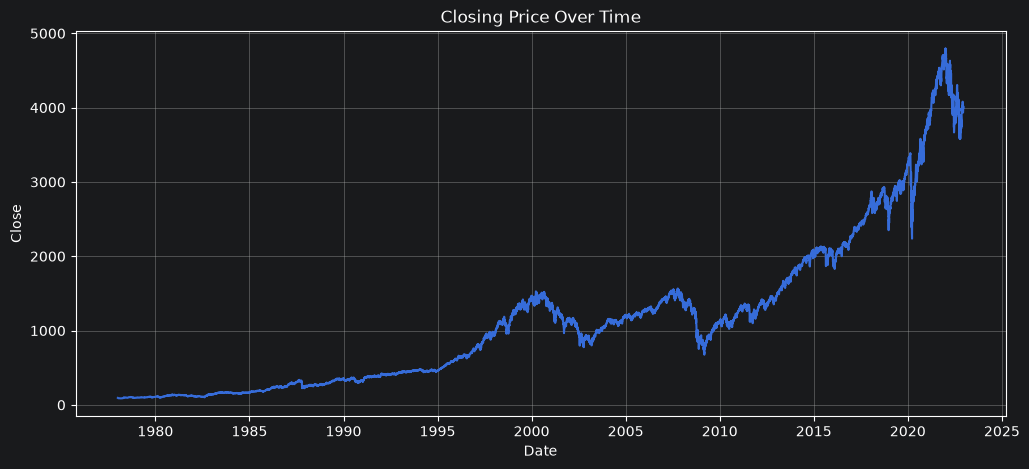

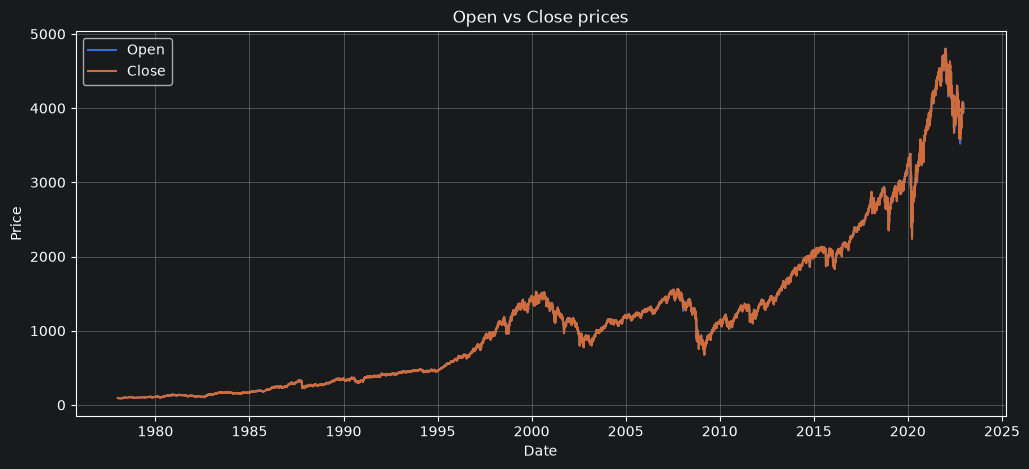

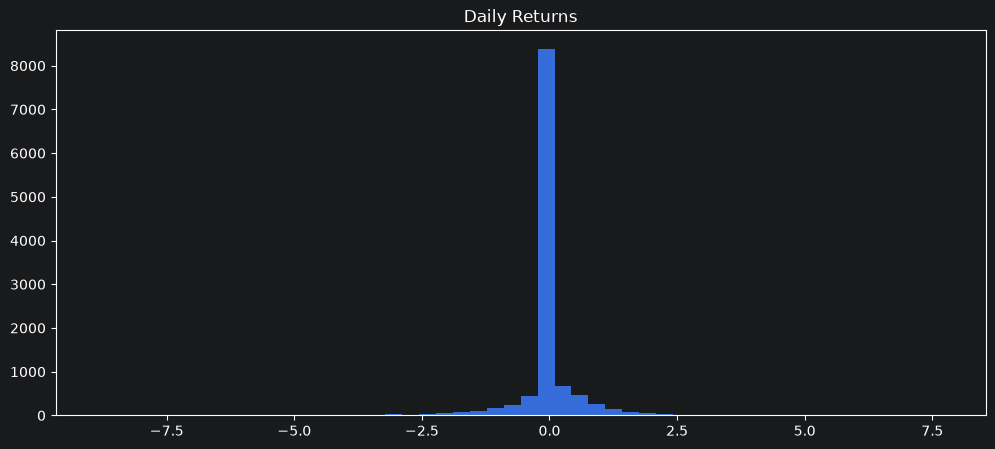

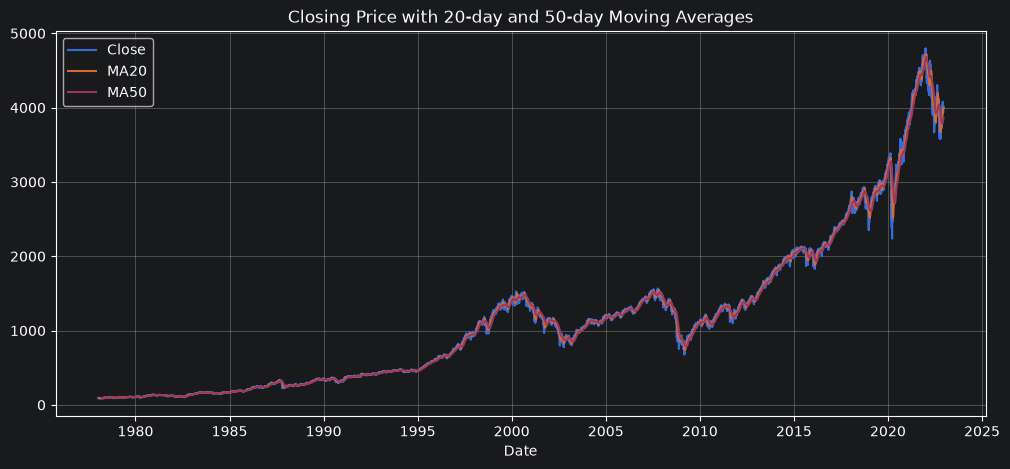

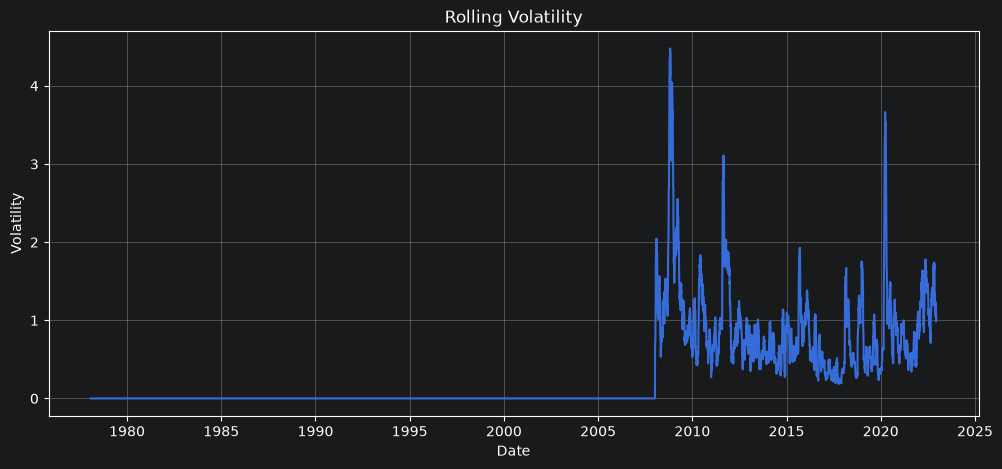

In [65]:
import matplotlib.pyplot as plt

# --- 1
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Closing Price Over Time")
plt.grid(True)
plt.show()
# --- 2
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Open"], label="Open")
plt.plot(df.index, df["Close"], label="Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.title("Open vs Close prices")
plt.grid(True)
plt.show()
# --- 3
plt.figure(figsize=(12, 5))
plt.hist(df["Return"], bins=50)
plt.title("Daily Returns")
plt.show()
# --- 4
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"], label="Close")
plt.plot(df.index, df["MA20"], label="MA20")
plt.plot(df.index, df["MA50"], label="MA50")
plt.xlabel("Date")
plt.legend()
plt.title("Closing Price with 20-day and 50-day Moving Averages")
plt.grid(True)
plt.show()
# --- 5
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Volatility"])
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Rolling Volatility")
plt.grid(True)
plt.show()